# 00 — Análise do alvo: o gate empírico

Ponto de decisão bloqueante: as trilhas de modelagem não devem rodar antes deste
notebook estar executado. Cada seção mede uma escolha que o projeto tinha feito
por hipótese, e fecha com um veredito curto. **O raciocínio, as alternativas
rejeitadas e o histórico de revisão ficam em [docs/03-decisoes.md](../docs/03-decisoes.md)** — aqui só a
medição e o que ela decide.

| # | Pergunta | Decisão |
|---|---|---|
| 1 | Equipamentos é mesmo o melhor alvo? | D-01, D-18 |
| 2 | As chaves naturais declaradas são únicas? | D-27, D-38 |
| 3 | A densidade anual é suficiente? | D-04, D-10 |
| 4 | As coordenadas dão para a trilha geográfica? | D-15, D-22 |
| 5 | Que colunas o filtro empírico rejeita na série inteira? | D-06 |
| 6 | A regressão da quantidade sustenta tarefa secundária? | D-02, D-37 |

**Recorte:** estado de São Paulo (D-21). `RECORTE` é prefixo de código IBGE —
`'355030'` volta para a capital, `None` dá o país.

In [24]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import schema
from src.config.paths import PRIMARY_FOLDER
from src.etl import changes
from src.etl.extract import PERIODOS_ANUAIS
from src.ml.graph import RECORTE_PADRAO, filtro_recorte_sql

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

RECORTE = RECORTE_PADRAO          # '35' = estado de SP; '355030' = capital
FILTRO = filtro_recorte_sql(RECORTE)

PERIODOS = changes.periodos_disponiveis()
con = duckdb.connect()
con.execute("SET memory_limit='2GB'")

print(f"Recorte: {RECORTE!r}  ->  {FILTRO}")
print(f"Snapshots na camada primária: {PERIODOS}")
print(f"Transições: {[str(t) for t in changes.transicoes(PERIODOS)]}")
print(f"Tabelas no escopo: {len(schema.FACT_TABLES)}")

assert len(PERIODOS) >= 2, "rode `python -m src.etl.pipeline` antes deste notebook"
faltando = [p for p in PERIODOS_ANUAIS if p not in PERIODOS]
if faltando:
    print(f"\n[ATENÇÃO] {len(PERIODOS)} de {len(PERIODOS_ANUAIS)} snapshots "
          f"convertidos; faltam {faltando}. Qualquer número abaixo é parcial — "
          "foi exatamente assim que D-17 registrou um teto de cobertura errado.")
extra = [p for p in PERIODOS if p not in PERIODOS_ANUAIS]
if extra:
    print(f"\n[NOTA] snapshots fora da amostra canônica presentes: {extra}")


Recorte: '35'  ->  "co_municipio_gestor" LIKE '35%'
Snapshots na camada primária: ['201701', '201801', '201901', '202001', '202101', '202201', '202301', '202401', '202501', '202601']
Transições: ['201701->201801', '201801->201901', '201901->202001', '202001->202101', '202101->202201', '202201->202301', '202301->202401', '202401->202501', '202501->202601']
Tabelas no escopo: 44


## 1. Qual tabela é o melhor alvo?

Quatro tabelas de fato ligadas ao estabelecimento cujo conteúdo varia no tempo. A
comparação é sobre a série inteira e dentro do recorte, porque um rótulo pode ser
denso no país e esparso na amostra (D-01 usou duas competências e contagem
nacional).

In [25]:
CANDIDATAS = {
    "rlEstabEquipamento": "co_equipamento",
    "rlEstabComplementar": "co_leito",
    "rlEstabServClass": "co_servico",
    "rlEstabInstFisiAssist": "co_instalacao",
}

def cobertura(tabela: str, col_item: str) -> pd.DataFrame:
    linhas = []
    for periodo in PERIODOS:
        fato = PRIMARY_FOLDER / periodo / f"{tabela}.parquet"
        raiz = PRIMARY_FOLDER / periodo / "tbEstabelecimento.parquet"
        if not fato.exists() or not raiz.exists():
            continue
        colunas = {r[0] for r in con.execute(
            f"DESCRIBE SELECT * FROM read_parquet('{fato}')").fetchall()}
        if col_item not in colunas:
            linhas.append({"periodo": periodo, "erro": f"sem coluna {col_item}"})
            continue
        linhas.append(con.execute(f'''
            WITH sel AS (
                SELECT DISTINCT co_unidade FROM read_parquet('{raiz}')
                WHERE {FILTRO}
            )
            SELECT '{periodo}' AS periodo,
                   (SELECT COUNT(*) FROM sel) AS estabelecimentos,
                   COUNT(*) AS linhas,
                   COUNT(DISTINCT f.co_unidade) AS com_registro,
                   COUNT(DISTINCT f."{col_item}") AS itens_distintos
            FROM read_parquet('{fato}') f JOIN sel USING (co_unidade)
        ''').df().iloc[0].to_dict())
    df = pd.DataFrame(linhas)
    if "com_registro" in df:
        df["cobertura_%"] = (100 * df["com_registro"] / df["estabelecimentos"]).round(1)
    return df

for tabela, col in CANDIDATAS.items():
    print(f"\n{'=' * 78}\n{tabela}  (item = {col})\n{'=' * 78}")
    print(cobertura(tabela, col).to_string(index=False))


rlEstabEquipamento  (item = co_equipamento)
periodo  estabelecimentos  linhas  com_registro  itens_distintos  cobertura_%
 201701             80073  200764         42563               82         53.2
 201801             84712  213637         44736               82         52.8
 201901             89606  226403         46967               82         52.4
 202001             95367  241988         49745               97         52.2
 202101            100264  255294         51983               98         51.8
 202201            106365  268445         54624               98         51.4
 202301            112954  281990         57782               98         51.2
 202401            120881  295740         61172               98         50.6
 202501            136561  311281         65634               99         48.1
 202601            146500  326296         69442               99         47.4

rlEstabComplementar  (item = co_leito)
periodo  estabelecimentos  linhas  com_registro  itens_di

### O espaço de rótulos de cada candidata

Cobertura alta não basta. Decide quantos **eventos de aquisição** cada candidata
gera e qual prevalência resulta.

In [26]:
def espaco_de_rotulos(tabela: str, col_item: str) -> pd.DataFrame:
    linhas = []
    for t in changes.transicoes(PERIODOS):
        a = PRIMARY_FOLDER / t.origem / f"{tabela}.parquet"
        b = PRIMARY_FOLDER / t.destino / f"{tabela}.parquet"
        raiz = PRIMARY_FOLDER / t.origem / "tbEstabelecimento.parquet"
        if not (a.exists() and b.exists() and raiz.exists()):
            continue
        linhas.append(con.execute(f'''
            WITH sel AS (
                SELECT DISTINCT co_unidade FROM read_parquet('{raiz}')
                WHERE {FILTRO}
            ),
            itens AS (
                SELECT DISTINCT "{col_item}" FROM read_parquet('{b}')
                WHERE "{col_item}" IS NOT NULL
            ),
            tinha AS (
                SELECT DISTINCT co_unidade, "{col_item}"
                FROM read_parquet('{a}') JOIN sel USING (co_unidade)
            ),
            tem AS (
                SELECT DISTINCT co_unidade, "{col_item}"
                FROM read_parquet('{b}') JOIN sel USING (co_unidade)
            ),
            candidatos AS (
                SELECT s.co_unidade, i."{col_item}"
                FROM sel s CROSS JOIN itens i
                EXCEPT SELECT * FROM tinha
            )
            SELECT '{t.destino}' AS transicao,
                   (SELECT COUNT(*) FROM itens) AS itens,
                   COUNT(*) AS candidatos,
                   COUNT(m.co_unidade) AS aquisicoes
            FROM candidatos c
            LEFT JOIN tem m USING (co_unidade, "{col_item}")
        ''').df().iloc[0].to_dict())
    df = pd.DataFrame(linhas)
    if "aquisicoes" in df:
        df["prevalencia_%"] = (100 * df["aquisicoes"] / df["candidatos"]).round(4)
    return df

resumos = {t: espaco_de_rotulos(t, c) for t, c in CANDIDATAS.items()}
for tabela, df in resumos.items():
    print(f"\n{'=' * 78}\n{tabela}\n{'=' * 78}")
    print(df.to_string(index=False))


rlEstabEquipamento
transicao  itens  candidatos  aquisicoes  prevalencia_%
   201801     82     6365222        3336         0.0524
   201901     82     6732747        2891         0.0429
   202001     99     8644591        4443         0.0514
   202101     99     9199345        5585         0.0607
   202201     99     9670842        4836         0.0500
   202301     99    10261690        4077         0.0397
   202401     99    10900456        4409         0.0404
   202501     99    11671480        4994         0.0428
   202601     99    13208275        6309         0.0478

rlEstabComplementar
transicao  itens  candidatos  aquisicoes  prevalencia_%
   201801     66     5276226         287         0.0054
   201901     66     5582220         256         0.0046
   202001     66     5904985         316         0.0054
   202101     69     6571149         611         0.0093
   202201     69     6908509         366         0.0053
   202301     69     7329274         342         0.0047
   2024

In [27]:
comparacao = pd.DataFrame([
    {
        "tabela": tabela,
        "itens": int(df["itens"].max()),
        "candidatos": int(df["candidatos"].sum()),
        "aquisicoes": int(df["aquisicoes"].sum()),
        "prevalencia_mediana_%": round(float(df["prevalencia_%"].median()), 4),
    }
    for tabela, df in resumos.items()
    if "aquisicoes" in df and not df.empty
]).sort_values("aquisicoes", ascending=False)

print(comparacao.to_string(index=False))

               tabela  itens  candidatos  aquisicoes  prevalencia_mediana_%
     rlEstabServClass     72    64849904       42208                 0.0514
   rlEstabEquipamento     99    86654648       40880                 0.0478
rlEstabInstFisiAssist     56    44313553       24021                 0.0483
  rlEstabComplementar     69    63100217        3062                 0.0047


> **Veredito 1 — alvo: `rlEstabEquipamento`.**
>
> Nove transições, recorte estadual: `rlEstabServClass` lidera em volume
> (42.208 aquisições contra 40.880), `rlEstabInstFisiAssist` vem terceira
> (24.021) e `rlEstabComplementar` fica uma ordem de grandeza abaixo (3.062).
>
> Equipamentos permanece o alvo por razões que não são volume: é **recurso
> físico** com custo e prazo, contra uma classificação administrativa em que
> "adquirir um serviço" pode ser só reclassificar; e o vocabulário é maior — 99
> itens contra 72 — o que dá mais o que ranquear por estabelecimento, onde MAP@k
> mede. `rlEstabServClass` fica como alvo alternativo de primeira escolha.
>
> **Cuidado ao ler a coluna de prevalência:** ela é a **mediana** das prevalências
> por transição. O número citado no README e em D-32 é o **agregado**, razão entre
> os totais — 0,0472% para equipamentos, contra 0,0478% de mediana. Para
> `rlEstabServClass` os dois divergem bem mais (0,0651% contra 0,0514%), porque as
> transições recentes concentram eventos e o agregado as pondera por volume.
>
> Registrado em D-01, D-18, D-21; série de dez snapshots em D-29.

## 2. As chaves naturais declaradas são únicas?

Sem chave única, `src/etl/changes.py` não distingue modificação de remoção
seguida de inserção, e a taxa de mudança sai inflada — cada alteração conta duas
vezes. A primeira célula mede duplicatas da chave declarada em cada snapshot; a
segunda diz que coluna a mais resolveria, se houvesse duplicata.

In [28]:
def unicidade(tabela: str) -> pd.DataFrame:
    chave = schema.CNES_NATURAL_KEY.get(tabela)
    if not chave:
        return pd.DataFrame([{"tabela": tabela, "obs": "sem chave natural declarada"}])
    cols = ", ".join(f'"{c}"' for c in chave)
    linhas = []
    for periodo in PERIODOS:
        p = PRIMARY_FOLDER / periodo / f"{tabela}.parquet"
        if not p.exists():
            continue
        r = con.execute(f'''
            SELECT COUNT(*) AS linhas,
                   COUNT(*) - COUNT(DISTINCT ({cols})) AS duplicadas
            FROM read_parquet('{p}')
        ''').df().iloc[0]
        linhas.append({
            "tabela": tabela, "periodo": periodo, "chave": " + ".join(chave),
            "linhas": int(r["linhas"]), "duplicadas": int(r["duplicadas"]),
        })
    return pd.DataFrame(linhas)

for tabela in schema.CNES_NATURAL_KEY:
    print(unicidade(tabela).to_string(index=False), "\n")

           tabela periodo                                                         chave  linhas  duplicadas
rlAdmGerenciaCnes  201701 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy     878           0
rlAdmGerenciaCnes  201801 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    1045           0
rlAdmGerenciaCnes  201901 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    1259           0
rlAdmGerenciaCnes  202001 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    1759           0
rlAdmGerenciaCnes  202101 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    2258           0
rlAdmGerenciaCnes  202201 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    2725           0
rlAdmGerenciaCnes  202301 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    3319           0
rlAdmGerenciaCnes  202401 nu_cnpj_adm + co_unidade + to_chardt_vigencia_inicialddmmyyyy    3961           0
rlAdmGerenciaCnes  202501 nu

In [29]:
# Se houvesse duplicadas: que coluna a mais resolveria?
def chave_minima(tabela: str, periodo: str) -> pd.DataFrame:
    p = PRIMARY_FOLDER / periodo / f"{tabela}.parquet"
    if not p.exists():
        return pd.DataFrame()
    base = list(schema.CNES_NATURAL_KEY.get(tabela, ()))
    extras = [c for c in schema.CNES_EXTRACT_COLUMNS[tabela]
              if c not in base and not c.startswith("to_char")]
    linhas = []
    for extra in [None, *extras]:
        cols = base + ([extra] if extra else [])
        if not cols:
            continue
        expr = ", ".join(f'"{c}"' for c in cols)
        dup = con.execute(f'''SELECT COUNT(*) - COUNT(DISTINCT ({expr}))
                              FROM read_parquet('{p}')''').fetchone()[0]
        linhas.append({"acrescentando": extra or "(chave declarada)",
                       "duplicadas": int(dup)})
    return pd.DataFrame(linhas).sort_values("duplicadas")

for tabela in schema.CNES_NATURAL_KEY:
    print(f"\n{tabela} em {PERIODOS[-1]}:")
    print(chave_minima(tabela, PERIODOS[-1]).to_string(index=False))


rlAdmGerenciaCnes em 202601:
    acrescentando  duplicadas
(chave declarada)           0

rlCooperativa em 202601:
    acrescentando  duplicadas
(chave declarada)           0

rlEquipeAldeia em 202601:
    acrescentando  duplicadas
(chave declarada)           0
       co_unidade           0

rlEquipeNasfEsf em 202601:
    acrescentando  duplicadas
(chave declarada)           0
    nu_sequencial           0
       co_unidade           0
    tp_equipe_esf           0
      co_cnes_esf           0
  co_segmento_esf           0

rlEstabAtendPrestConv em 202601:
    acrescentando  duplicadas
(chave declarada)           0

rlEstabAtenPsico em 202601:
      acrescentando  duplicadas
  (chave declarada)           0
       tp_estrutura           0
    st_parceria_ong           0
        nu_cnpj_ong           0
nu_vagas_acol_notur           0
co_profissional_sus           0
             co_cbo           0
     tp_sus_nao_sus           0
     ind_vinculacao           0
 co_cnes_referencia       

> **Veredito 2 — chaves naturais: 44 de 44, todas medidas.**
>
> Zero duplicatas em todos os dez snapshots, com uma exceção conhecida:
> `rlEstabSipac` tem 8 a 59 linhas por snapshot **idênticas em toda coluna
> exportada** — repetição na origem, que nenhuma chave separa. Para ela a
> unicidade vale a menos de linha repetida.
>
> A chave contém sempre a PRIMARY KEY do dicionário. Foi o que resolveu
> `rlEstabServClass`, cuja identidade dependia de `co_end_compl` — coluna sem
> valor descritivo, descartada pelo filtro semântico e por isso invisível para a
> busca da célula acima, que só percorre o que já está declarado.
>
> A classificação `alterada` do diff é confiável para todas as tabelas.
>
> Registrado em D-27 e D-38.

## 3. A densidade anual é suficiente?

D-04 fixou snapshots anuais provisoriamente. A pergunta de D-10 é se um ano de
intervalo esconde ciclos: taxa alta significa intervalo agregando eventos que se
queria separar; taxa estável e moderada significa intervalo adequado.

In [30]:
try:
    taxa = changes.taxa_de_mudanca()
except FileNotFoundError as e:
    print(e)
    taxa = None

if taxa is not None:
    foco = taxa[taxa["tabela"].isin(CANDIDATAS)]
    print(foco[["tabela", "periodo_destino", "linhas_origem", "linhas_destino",
                "inserida", "removida", "alterada", "taxa_mudanca",
                "chave_declarada"]].to_string(index=False))

               tabela periodo_destino  linhas_origem  linhas_destino  inserida  removida  alterada  taxa_mudanca  chave_declarada
  rlEstabComplementar          201801          53489           53900      2566      2155      5238      0.184768             True
  rlEstabComplementar          201901          53900           54763      2115      1252      4446      0.142669             True
  rlEstabComplementar          202001          54763           55299      1935      1399      4857      0.148122             True
  rlEstabComplementar          202101          55299           57696      4397      2000      6272      0.219582             True
  rlEstabComplementar          202201          57696           59394      3335      1637      6893      0.199768             True
  rlEstabComplementar          202301          59394           58317      2604      3681      6634      0.217514             True
  rlEstabComplementar          202401          58317           59133      2313      1497  

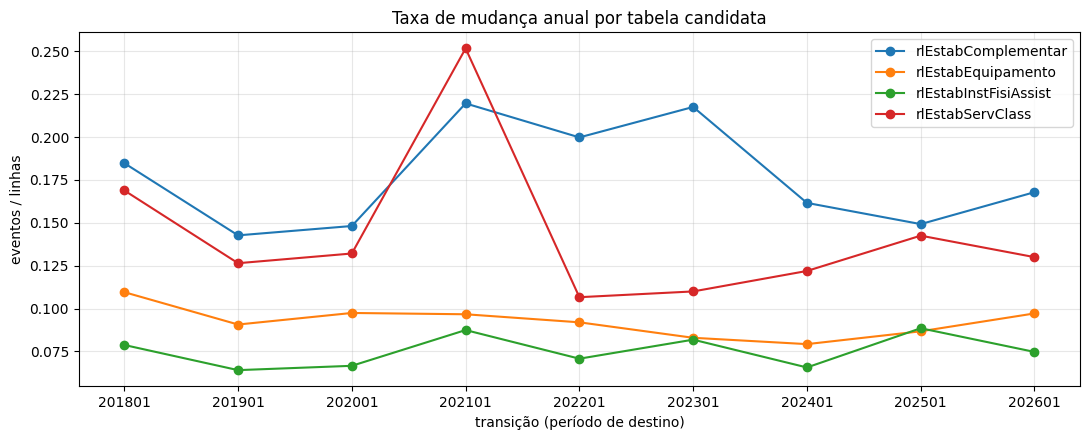

Linha tracejada = sem chave natural declarada: cada modificação conta
como remoção mais inserção, então a taxa está superestimada.


In [31]:
if taxa is not None and not taxa.empty:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for tabela, grupo in taxa[taxa["tabela"].isin(CANDIDATAS)].groupby("tabela"):
        estilo = "-o" if grupo["chave_declarada"].all() else "--x"
        ax.plot(grupo["periodo_destino"], grupo["taxa_mudanca"], estilo, label=tabela)
    ax.set_title("Taxa de mudança anual por tabela candidata")
    ax.set_xlabel("transição (período de destino)")
    ax.set_ylabel("eventos / linhas")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Linha tracejada = sem chave natural declarada: cada modificação conta")
    print("como remoção mais inserção, então a taxa está superestimada.")

> **Veredito 3 — densidade: anual mantida.**
>
> Taxa de mudança de `rlEstabEquipamento` nas nove transições: 0,110 · 0,091 ·
> 0,097 · 0,097 · 0,092 · 0,083 · 0,079 · 0,087 · 0,097. Mediana **0,092**,
> amplitude 0,079–0,110, sem pico nas transições de pandemia.
>
> Série plana é o que indica que o intervalo não agrega eventos que se queira
> separar. Não há ciclo escondido que justifique o custo de densificar.
>
> A mudança é dominada por inserção — 60 a 88 mil por transição contra 6 a 14 mil
> remoções —, coerente com o crescimento do cadastro.
>
> **Taxa perto de 1,0 é sinal de chave ou de formato, não de dado**: já apareceu
> por chave natural faltando e por alargamento de coluna no CNES.
>
> Registrado em D-10; os dois defeitos em D-27, D-30 e D-31.

## 4. A trilha geográfica é viável?

A trilha 3 depende inteiramente de `nu_latitude` e `nu_longitude`. Duas medições:
cobertura plausível por snapshot, e cobertura **acumulada** — estabelecimento
posicionado em qualquer competência pode ser nó, porque D-15 trata a posição como
invariante no tempo.

A célula de abertura afirma quantos snapshots existem de propósito: D-17 fixou um
teto errado por ter medido seis de nove.

In [40]:
def cobertura_geografica() -> pd.DataFrame:
    linhas = []
    for periodo in PERIODOS:
        p = PRIMARY_FOLDER / periodo / "tbEstabelecimento.parquet"
        if not p.exists():
            continue
        linhas.append(con.execute(f'''
            SELECT '{periodo}' AS periodo,
                   COUNT(*) AS estabelecimentos,
                   COUNT(nu_latitude) AS com_coordenada,
                   SUM(CASE WHEN nu_latitude BETWEEN -34 AND 6
                             AND nu_longitude BETWEEN -74 AND -34
                             AND NOT (nu_latitude = 0 AND nu_longitude = 0)
                            THEN 1 ELSE 0 END) AS plausivel
            FROM read_parquet('{p}') WHERE {FILTRO}
        ''').df().iloc[0].to_dict())
    df = pd.DataFrame(linhas)
    df["plausivel_%"] = (100 * df["plausivel"] / df["estabelecimentos"]).round(2)
    return df

geo = cobertura_geografica()
print(geo.to_string(index=False))

periodo  estabelecimentos  com_coordenada  plausivel  plausivel_%
 201701             80073             901      901.0         1.13
 201801             84712            6539     6537.0         7.72
 201901             89606           23680    23654.0        26.40
 202001             95367           68362    68357.0        71.68
 202101            100264           77673    77663.0        77.46
 202201            106365           84966    84948.0        79.86
 202301            112954           92349    92328.0        81.74
 202401            120881          100883   100861.0        83.44
 202501            136561          117016   116992.0        85.67
 202601            146500          127859   127852.0        87.27


In [33]:
# Cobertura acumulada: um estabelecimento posicionado em QUALQUER snapshot pode
# ser usado, porque D-15 trata a posição como invariante no tempo. É o teto real
# da trilha 3. `union_by_name` é obrigatório aqui — três tabelas têm colunas que
# somem e voltam entre competências (D-20).
arquivos = [str(PRIMARY_FOLDER / p / "tbEstabelecimento.parquet")
            for p in PERIODOS
            if (PRIMARY_FOLDER / p / "tbEstabelecimento.parquet").exists()]
lista = ", ".join(f"'{a}'" for a in arquivos)

acumulada = con.execute(f'''
    WITH sel AS (
        SELECT co_unidade, nu_latitude, nu_longitude
        FROM read_parquet([{lista}], union_by_name=true) WHERE {FILTRO}
    )
    SELECT COUNT(DISTINCT co_unidade) AS estabelecimentos,
           COUNT(DISTINCT CASE WHEN nu_latitude BETWEEN -34 AND 6
                                AND nu_longitude BETWEEN -74 AND -34
                                AND NOT (nu_latitude = 0 AND nu_longitude = 0)
                               THEN co_unidade END) AS posicionaveis
    FROM sel
''').df()
acumulada["cobertura_acumulada_%"] = (
    100 * acumulada["posicionaveis"] / acumulada["estabelecimentos"]).round(2)
print(acumulada.to_string(index=False))
print(f"\nMelhor snapshot isolado: {geo['plausivel_%'].max():.2f}%")
print("Se a acumulada mal supera o melhor snapshot, o teto é estrutural: quem")
print("não tem coordenada hoje nunca teve. Foi o que se observou (D-17, D-22).")

 estabelecimentos  posicionaveis  cobertura_acumulada_%
           146679         127868                  87.18

Melhor snapshot isolado: 87.27%
Se a acumulada mal supera o melhor snapshot, o teto é estrutural: quem
não tem coordenada hoje nunca teve. Foi o que se observou (D-17, D-22).


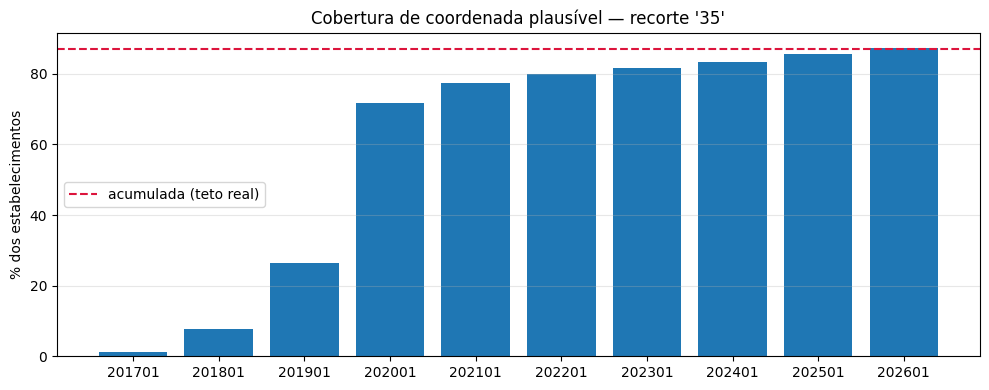

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(geo["periodo"], geo["plausivel_%"])
ax.axhline(float(acumulada["cobertura_acumulada_%"].iloc[0]), color="crimson",
           linestyle="--", label="acumulada (teto real)")
ax.set_title(f"Cobertura de coordenada plausível — recorte {RECORTE!r}")
ax.set_ylabel("% dos estabelecimentos")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

> **Veredito 4 — trilha geográfica viável, 87,3% no estado.**
>
> Cobertura plausível: 1,1% em 201701, 71,7% em 202001, **87,27%** em 202601.
> Degrau claro em 2020, quando o CNES passou a exigir geolocalização.
>
> A acumulada sobre as dez competências é **87,18%**, abaixo do melhor snapshot
> isolado porque o denominador inclui estabelecimentos que só existiram em
> competências antigas, sem coordenada. O teto é estrutural: quem não tem
> coordenada hoje não teve antes.
>
> **Obrigação que isso cria:** comparar a trilha 3 com as outras duas exige o
> mesmo subconjunto de nós, senão a comparação mede diferença de amostra em vez de
> diferença de estrutura. `Previsao.mascara_de_entidades()` existe para isso.
>
> Registrado em D-15 e D-22; o teto de 57% de D-17 está superado.

## 5. O filtro empírico sobre a série inteira

D-06 aplicou o filtro em duas competências. Aqui ele é reaplicado sobre a série:
coluna degenerada é a que está 100% nula, ou constante, em **todos** os snapshots.

A segunda célula faz o lado simétrico — coluna que existe no CSV e o doc não
declara — e precisa dos ZIPs em `data/01_raw`, que não são versionados.

O `union_by_name=true` não é opcional: três das 44 tabelas têm colunas que somem e
voltam entre competências (D-20).

In [35]:
def triagem_empirica() -> pd.DataFrame:
    linhas = []
    for tabela, colunas in schema.CNES_EXTRACT_COLUMNS.items():
        arquivos = [PRIMARY_FOLDER / p / f"{tabela}.parquet" for p in PERIODOS]
        arquivos = [a for a in arquivos if a.exists()]
        if not arquivos:
            linhas.append({"tabela": tabela, "coluna": "*",
                           "motivo": "tabela ausente em todos os snapshots"})
            continue
        lista = ", ".join(f"'{a}'" for a in arquivos)
        fonte = f"read_parquet([{lista}], union_by_name=true)"
        presentes = {r[0] for r in con.execute(
            f"DESCRIBE SELECT * FROM {fonte}").fetchall()}
        total = con.execute(f"SELECT COUNT(*) FROM {fonte}").fetchone()[0]
        if total == 0:
            linhas.append({"tabela": tabela, "coluna": "*",
                           "motivo": "vazia em todos os snapshots"})
            continue

        usaveis = [c for c in colunas if c in presentes]
        for c in colunas:
            if c not in presentes:
                linhas.append({"tabela": tabela, "coluna": c,
                               "motivo": "ausente do Parquet"})
        if not usaveis:
            continue
        # Uma query por tabela, não uma por coluna: 44 tabelas x ~9 colunas x 9
        # snapshots seriam milhares de varreduras dos mesmos arquivos.
        agregados = ", ".join(
            f'COUNT("{c}") AS nn{i}, COUNT(DISTINCT "{c}") AS nd{i}'
            for i, c in enumerate(usaveis))
        r = con.execute(f"SELECT {agregados} FROM {fonte}").df().iloc[0]
        for i, c in enumerate(usaveis):
            if r[f"nn{i}"] == 0:
                linhas.append({"tabela": tabela, "coluna": c,
                               "motivo": "100% nula em todos os snapshots"})
            elif r[f"nd{i}"] <= 1:
                linhas.append({"tabela": tabela, "coluna": c,
                               "motivo": "constante em todos os snapshots"})
    return pd.DataFrame(linhas)

rejeitadas = triagem_empirica()
uteis = sum(len(v) for v in schema.CNES_USEFUL_COLUMNS.values())
print(f"{len(rejeitadas)} rejeições sobre {len(PERIODOS)} snapshots, "
      f"de {uteis} colunas hoje `util`:\n")
if not rejeitadas.empty:
    print(rejeitadas.sort_values(["motivo", "tabela"]).to_string(index=False))
else:
    print("Nenhuma — o filtro já foi aplicado e o doc está em dia.")

0 rejeições sobre 10 snapshots, de 393 colunas hoje `util`:

Nenhuma — o filtro já foi aplicado e o doc está em dia.


In [41]:
# O lado simétrico da triagem: coluna que existe no CSV e o doc não declara.
# A célula acima só examina o que o doc já lista, então nunca acharia isto —
# foi assim que quatro colunas do CSV passaram nove competências sem avaliação.
# Lê apenas o header de cada CSV dentro do ZIP; não descompacta nada.
import re
import zipfile

from src.config.paths import RAW_FOLDER


def normaliza(nome: str) -> str:
    """Mesma transformação que o `normalize_names=True` do DuckDB aplica."""
    return re.sub(r"[^a-z0-9_]", "", nome.strip().lower())


def headers_do_zip(periodo: str) -> dict[str, list[str]]:
    caminho = RAW_FOLDER / f"BASE_DE_DADOS_CNES_{periodo}.ZIP"
    if not caminho.exists():
        return {}
    saida = {}
    with zipfile.ZipFile(caminho) as z:
        for info in z.infolist():
            nome = Path(info.filename).name
            if not nome.lower().endswith(".csv"):
                continue
            base = nome[:-4]
            if not re.fullmatch(r".*\d{6}", base):   # o sufixo é a competência
                continue
            with z.open(info) as f:
                cabecalho = f.readline().decode("ISO_8859_1").rstrip("\r\n")
            saida[base[:-6]] = [normaliza(c) for c in cabecalho.split(";")]
    return saida


PERIODOS_ZIP = [p for p in PERIODOS if (RAW_FOLDER / f"BASE_DE_DADOS_CNES_{p}.ZIP").exists()]
headers = {p: headers_do_zip(p) for p in PERIODOS_ZIP}

# Sem ZIP não há o que comparar, e as contagens abaixo sairiam zeradas — que é
# indistinguível de "nenhuma divergência". A camada 01_raw não é versionada.
if not PERIODOS_ZIP:
    print("[ATENÇÃO] nenhum ZIP em data/01_raw: esta verificação NÃO rodou. "
          "Os zeros abaixo são ausência de dado, não ausência de divergência.\n"
          "Rode `make etl` (ou `python -m src.etl.extract`) antes de confiar nela.")

nao_declaradas, doc_sem_csv = [], []
for tabela in schema.FACT_TABLES:
    declaradas = {c.nome for c in schema.tabela(tabela).colunas}
    materializadas = set(schema.CNES_EXTRACT_COLUMNS[tabela])
    for periodo in PERIODOS_ZIP:
        csv = headers[periodo].get(tabela)
        if csv is None:
            doc_sem_csv.append({"tabela": tabela, "periodo": periodo,
                                "obs": "tabela sem CSV nesta competência"})
            continue
        for c in csv:
            if c not in declaradas:
                nao_declaradas.append({"tabela": tabela, "coluna": c, "periodo": periodo})
        for c in materializadas - set(csv):
            doc_sem_csv.append({"tabela": tabela, "periodo": periodo,
                                "obs": f"coluna materializada ausente: {c}"})

print(f"colunas do CSV não declaradas no doc: {len(nao_declaradas)}")
if nao_declaradas:
    print(pd.DataFrame(nao_declaradas)
          .groupby(["tabela", "coluna"])["periodo"]
          .agg(["count", "min", "max"]).to_string())

print(f"\ncolunas `util`/`pendente` do doc ausentes de algum CSV: {len(doc_sem_csv)}")
if doc_sem_csv:
    print(pd.DataFrame(doc_sem_csv).groupby(["tabela", "obs"])["periodo"]
          .agg(["count", "min", "max"]).to_string())
    print("\nAusência intermitente é o padrão de D-20, não erro do doc: "
          "`to_parquet` projeta só o que existe em cada competência.")


[ATENÇÃO] nenhum ZIP em data/01_raw: esta verificação NÃO rodou. Os zeros abaixo são ausência de dado, não ausência de divergência.
Rode `make etl` (ou `python -m src.etl.extract`) antes de confiar nela.
colunas do CSV não declaradas no doc: 0

colunas `util`/`pendente` do doc ausentes de algum CSV: 0


> **Veredito 5 — filtro empírico: zero rejeições sobre as 394 colunas `util`.**
>
> É o resultado esperado, e o que ele diz é que o crivo de D-06 é estável — passar
> de duas para dez competências não aperta o filtro indefinidamente. Se esta
> célula voltar a apontar algo, doc e dados divergiram.
>
> A verificação simétrica só roda com os ZIPs presentes; sem eles imprime aviso, e
> os zeros não significam nada. Quando rodou, achou quatro colunas do CSV ausentes
> do doc — duas admitidas como `util`, uma descartada por ser 100% nula e uma que
> era divergência de nome.
>
> Registrado em D-06; as colunas intermitentes em D-20.

## 6. A tarefa secundária de regressão é viável?

D-02 registrou a regressão da quantidade como tarefa secundária sem medir se ela
sustenta um experimento. Três alvos diferentes cabem na mesma frase:

| Formulação | Alvo | Piso trivial |
|---|---|---|
| **Nível** | `qt_existente` em `t+1` | persistência: repetir a quantidade de `t` |
| **Variação** | `qt_existente(t+1) − qt_existente(t)` | prever zero |
| **Variação no SUS** | o mesmo sobre a parcela disponível ao SUS | prever zero |

A terceira tem obstáculo de dado: `qt_sus` só existe em 202601, então não há
série. O proxy possível é somar `qt_existente` das linhas marcadas por `tp_sus`.

Critério de decisão, fixado antes de medir:

1. **Fração de pares persistentes que muda.** 1% ou 2% e o alvo é quase todo zero.
2. **Dispersão entre os que mudam** — e movimento em mais de 10% dos pares.
3. **Piso trivial batível:** RMSE de prever zero contra o desvio padrão do delta.
   Se coincidem, não há variância a explicar.

Vale medir também o agregado por estabelecimento, que troca a dimensão de item por
mais variância.

In [37]:
# Onde a quantidade disponível ao SUS pode ser medida, e onde não pode.
TABELA_ALVO = "rlEstabEquipamento"

disponibilidade = []
for periodo in PERIODOS:
    p = PRIMARY_FOLDER / periodo / f"{TABELA_ALVO}.parquet"
    if not p.exists():
        continue
    colunas = {r[0] for r in con.execute(
        f"DESCRIBE SELECT * FROM read_parquet('{p}')").fetchall()}
    disponibilidade.append({
        "periodo": periodo,
        "qt_existente": "qt_existente" in colunas,
        "qt_uso": "qt_uso" in colunas,
        "qt_sus": "qt_sus" in colunas,      # nova em 202601 (D-29)
        "tp_sus": "tp_sus" in colunas,      # sinalizador, presente em toda a série
    })
print(pd.DataFrame(disponibilidade).to_string(index=False))
print("\nqt_sus em uma única competência não sustenta série: sem dois instantes,")
print("não há variação a prever. O proxy é somar qt_existente por tp_sus.")

# Distribuição das quantidades na competência mais recente, para dimensionar a
# variância disponível *entre* pares — o teto do que qualquer modelo poderia
# explicar no alvo de nível.
f = PRIMARY_FOLDER / PERIODOS[-1] / f"{TABELA_ALVO}.parquet"
raiz = PRIMARY_FOLDER / PERIODOS[-1] / "tbEstabelecimento.parquet"
print(f"\nDistribuição em {PERIODOS[-1]}, recorte {RECORTE!r}:")
print(con.execute(f"""
    WITH sel AS (SELECT DISTINCT co_unidade FROM read_parquet('{raiz}') WHERE {FILTRO})
    SELECT COUNT(*) AS linhas,
           ROUND(AVG(qt_existente), 3) AS media_exist,
           ROUND(STDDEV(qt_existente), 3) AS sd_exist,
           MEDIAN(qt_existente) AS mediana_exist,
           MAX(qt_existente) AS max_exist,
           ROUND(100.0 * SUM(CASE WHEN qt_existente = 1 THEN 1 ELSE 0 END) / COUNT(*), 1)
               AS pct_exist_igual_1,
           ROUND(100.0 * SUM(CASE WHEN qt_uso = qt_existente THEN 1 ELSE 0 END) / COUNT(*), 1)
               AS pct_uso_igual_exist
    FROM read_parquet('{f}') JOIN sel USING (co_unidade)
""").df().T.to_string(header=False))


periodo  qt_existente  qt_uso  qt_sus  tp_sus
 201701          True    True   False    True
 201801          True    True   False    True
 201901          True    True   False    True
 202001          True    True   False    True
 202101          True    True   False    True
 202201          True    True   False    True
 202301          True    True   False    True
 202401          True    True   False    True
 202501          True    True   False    True
 202601          True    True    True    True

qt_sus em uma única competência não sustenta série: sem dois instantes,
não há variação a prever. O proxy é somar qt_existente por tp_sus.

Distribuição em 202601, recorte '35':
linhas               326296.000
media_exist               2.704
sd_exist                 16.216
mediana_exist             1.000
max_exist              2622.000
pct_exist_igual_1        68.200
pct_uso_igual_exist      94.400


In [42]:
# A medição decisiva: variação por par persistente, e o piso trivial de prever zero.
#
# Só pares presentes nos DOIS snapshots entram. Par que aparece é aquisição, que é
# a tarefa primária; par que desaparece é remoção. A tarefa secundária pergunta
# outra coisa: dado que o equipamento já está lá, a quantidade se move?
CHAVE_PAR = ("co_unidade", "co_equipamento", "co_tipo_equipamento")


def variacao_por_par(coluna: str = "qt_existente") -> pd.DataFrame:
    chave = ", ".join(CHAVE_PAR)
    linhas = []
    for t in changes.transicoes(PERIODOS):
        a = PRIMARY_FOLDER / t.origem / f"{TABELA_ALVO}.parquet"
        b = PRIMARY_FOLDER / t.destino / f"{TABELA_ALVO}.parquet"
        raiz = PRIMARY_FOLDER / t.origem / "tbEstabelecimento.parquet"
        if not (a.exists() and b.exists() and raiz.exists()):
            continue
        linhas.append(con.execute(f"""
            WITH sel AS (
                SELECT DISTINCT co_unidade FROM read_parquet('{raiz}') WHERE {FILTRO}
            ),
            j AS (
                SELECT x."{coluna}" AS q0, y."{coluna}" AS q1
                FROM read_parquet('{a}') x
                JOIN read_parquet('{b}') y USING ({chave})
                JOIN sel s ON s.co_unidade = x.co_unidade
            )
            SELECT '{t.destino}' AS transicao,
                   COUNT(*) AS pares,
                   SUM(CASE WHEN q1 <> q0 THEN 1 ELSE 0 END) AS mudaram,
                   AVG(q1 - q0) AS media_delta,
                   STDDEV(q1 - q0) AS sd_delta,
                   MIN(q1 - q0) AS min_delta,
                   MAX(q1 - q0) AS max_delta,
                   SQRT(AVG((q1 - q0) * (q1 - q0))) AS rmse_prever_zero,
                   AVG(ABS(q1 - q0)) AS mae_prever_zero,
                   STDDEV(q1 - q0) FILTER (WHERE q1 <> q0) AS sd_entre_os_que_mudaram
            FROM j
        """).df().iloc[0].to_dict())
    df = pd.DataFrame(linhas)
    if not df.empty:
        df["pct_mudaram"] = (100 * df.mudaram / df.pares).round(3)
    return df


for coluna in ("qt_existente", "qt_uso"):
    print(f"\n{'=' * 78}\nvariação de {coluna} por par persistente\n{'=' * 78}")
    print(variacao_por_par(coluna)[
        ["transicao", "pares", "mudaram", "pct_mudaram", "media_delta", "sd_delta",
         "min_delta", "max_delta", "rmse_prever_zero", "mae_prever_zero",
         "sd_entre_os_que_mudaram"]
    ].to_string(index=False))

print("\nLeitura: se `pct_mudaram` for de poucos por cento e `rmse_prever_zero`")
print("praticamente igual a `sd_delta`, prever zero é quase ótimo — e a tarefa é")
print("de detecção rara, não de regressão. É o mesmo diagnóstico de D-03.")



variação de qt_existente por par persistente
transicao  pares  mudaram  pct_mudaram  media_delta  sd_delta  min_delta  max_delta  rmse_prever_zero  mae_prever_zero  sd_entre_os_que_mudaram
   201801 199362   2312.0        1.160     0.070199  4.437271       -525        832          4.437815         0.109414                40.771235
   201901 212520   2065.0        0.972     0.049275  3.384057       -107        899          3.384408         0.077593                33.965502
   202001 225078   2513.0        1.117     0.044802  3.098007       -118        888          3.098324         0.079706                29.052155
   202101 239482   2907.0        1.214     0.077279  4.914030      -1308       1375          4.914627         0.114059                44.158106
   202201 252999   3441.0        1.360     0.080846  4.910311       -952       1032          4.910967         0.125170                41.694296
   202301 266264   2752.0        1.034     0.022252  4.889445      -1299        952       

In [39]:
# Onde a variação se concentra, e as duas alternativas de desenho:
#   (a) agregar por estabelecimento — mais variância, sem a dimensão de item;
#   (b) restringir ao SUS via tp_sus — o proxy para o alvo que qt_sus não sustenta.
ultima = changes.transicoes(PERIODOS)[-1]
a = PRIMARY_FOLDER / ultima.origem / f"{TABELA_ALVO}.parquet"
b = PRIMARY_FOLDER / ultima.destino / f"{TABELA_ALVO}.parquet"
raiz = PRIMARY_FOLDER / ultima.origem / "tbEstabelecimento.parquet"
chave = ", ".join(CHAVE_PAR)

print(f"Concentração do delta em {ultima} (recorte {RECORTE!r}):")
print(con.execute(f"""
    WITH sel AS (SELECT DISTINCT co_unidade FROM read_parquet('{raiz}') WHERE {FILTRO}),
    j AS (
        SELECT y.qt_existente - x.qt_existente AS delta
        FROM read_parquet('{a}') x
        JOIN read_parquet('{b}') y USING ({chave})
        JOIN sel s ON s.co_unidade = x.co_unidade
    )
    SELECT delta, COUNT(*) AS pares,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 3) AS pct
    FROM j GROUP BY delta ORDER BY pares DESC LIMIT 10
""").df().to_string(index=False))


def variacao_agregada(filtro_sus: str = "") -> pd.DataFrame:
    """Delta do total de equipamentos por estabelecimento, com ou sem recorte SUS."""
    linhas = []
    for t in changes.transicoes(PERIODOS):
        a = PRIMARY_FOLDER / t.origem / f"{TABELA_ALVO}.parquet"
        b = PRIMARY_FOLDER / t.destino / f"{TABELA_ALVO}.parquet"
        raiz = PRIMARY_FOLDER / t.origem / "tbEstabelecimento.parquet"
        if not (a.exists() and b.exists() and raiz.exists()):
            continue
        onde = f"WHERE {filtro_sus}" if filtro_sus else ""
        linhas.append(con.execute(f"""
            WITH sel AS (
                SELECT DISTINCT co_unidade FROM read_parquet('{raiz}') WHERE {FILTRO}
            ),
            t0 AS (SELECT co_unidade, SUM(qt_existente) AS total
                   FROM read_parquet('{a}') {onde} GROUP BY 1),
            t1 AS (SELECT co_unidade, SUM(qt_existente) AS total
                   FROM read_parquet('{b}') {onde} GROUP BY 1),
            j AS (
                SELECT t0.total AS q0, t1.total AS q1
                FROM t0 JOIN t1 USING (co_unidade) JOIN sel USING (co_unidade)
            )
            SELECT '{t.destino}' AS transicao,
                   COUNT(*) AS estabelecimentos,
                   ROUND(100.0 * SUM(CASE WHEN q1 <> q0 THEN 1 ELSE 0 END) / COUNT(*), 2)
                       AS pct_mudaram,
                   AVG(q0) AS media_total, STDDEV(q0) AS sd_total,
                   AVG(q1 - q0) AS media_delta, STDDEV(q1 - q0) AS sd_delta,
                   SQRT(AVG((q1 - q0) * (q1 - q0))) AS rmse_prever_zero,
                   AVG(ABS(q1 - q0)) AS mae_prever_zero
            FROM j
        """).df().iloc[0].to_dict())
    return pd.DataFrame(linhas)


print(f"\n{'=' * 78}\n(a) total de equipamentos por estabelecimento\n{'=' * 78}")
print(variacao_agregada().to_string(index=False))

print(f"\n{'=' * 78}\n(b) idem, só linhas disponíveis ao SUS (tp_sus = '1')\n{'=' * 78}")
print(variacao_agregada("tp_sus = '1'").to_string(index=False))

print("\nA comparação que decide o desenho: sd_delta do agregado contra sd_delta do")
print("par. Se o agregado tiver variância substancialmente maior, a formulação por")
print("estabelecimento é a única com sinal — ao custo de perder a dimensão de item.")


Concentração do delta em 202501->202601 (recorte '35'):
 delta  pares    pct
     0 303961 98.659
     1   1119  0.363
    -1    716  0.232
     2    416  0.135
    -2    315  0.102
     3    239  0.078
     4    146  0.047
    -3    101  0.033
     5     83  0.027
     7     66  0.021

(a) total de equipamentos por estabelecimento
transicao  estabelecimentos  pct_mudaram  media_total  sd_total  media_delta  sd_delta  rmse_prever_zero  mae_prever_zero
   201801             42444         2.84    11.641952 62.941565     0.412143 15.850198         15.855369         0.555249
   201901             44635         2.42    11.896830 68.085708     0.313140 13.013364         13.016985         0.407998
   202001             46884         3.02    12.106540 71.002481     0.350162 11.978333         11.983322         0.478649
   202101             49456         4.16    12.271635 72.035729     0.618732 24.552985         24.560532         0.801318
   202201             51731         3.47    12.843363 82

> **Veredito 6 — regressão da quantidade: rejeitada, pelo critério escrito antes.**
>
> **2.276.691 pares persistentes nas nove transições, 25.475 mudam de quantidade:
> 1,119%.**
>
> - **Critério 1 falha.** Movimento de 0,86% a 1,36% por transição. Em 202601,
>   98,659% dos pares têm Δ = 0 e ±1 responde por 0,595%.
> - **Critério 3 falha.** RMSE de prever zero é igual ao desvio padrão do alvo até
>   a terceira decimal em todas as transições — sintoma definicional de que não há
>   variância a explicar. O MAE de prever zero fica entre 0,06 e 0,13 equipamento.
> - **Critério 2 é o que quase passa.** Agregar por estabelecimento eleva o desvio
>   do delta de 2,8–4,9 para 11,2–25,9, mas só 2,4% a 4,3% dos estabelecimentos
>   mudam o total e o MAE de prever zero continua abaixo de um equipamento. Ganhar
>   variância mudando a unidade de análise não cria sinal.
>
> **A pouca variância que existe é ruído de cadastro:** o delta chega a −1.308 e
> +1.375 num único par (estabelecimento, tipo) em um ano. Nenhuma unidade adquire
> mil aparelhos de um tipo em doze meses — um modelo treinado nesse alvo
> aprenderia a prever correção de registro.
>
> A variante no SUS não é mensurável hoje: `qt_sus` tem uma única competência, e o
> proxy por `tp_sus` herda a mesma esparsidade.
>
> A formulação correta de evento raro é a que o projeto já usa: classificação
> binária de aquisição. Registrado em D-37.

## Decisão final

Seis vereditos fechados, cinco confirmando e um rejeitando. O registro completo —
evidência, alternativas descartadas e consequências no código — está em
[docs/03-decisoes.md](../docs/03-decisoes.md).

| Decisão | Status | Valor fixado | Evidência |
|---|---|---|---|
| D-01 / D-18 alvo | fechada | `rlEstabEquipamento` | 40.880 aquisições; serviços empatam em volume mas são classificação administrativa |
| D-27 / D-38 chave natural | fechada | 44 de 44 declaradas | zero duplicatas nos dez snapshots; `rlEstabSipac` a menos de linha repetida |
| D-04 / D-10 densidade | fechada | dez snapshots anuais | mediana 0,092, amplitude 0,079–0,110 |
| D-15 / D-22 trilha 3 | fechada | 87,3% no estado | teto estrutural; acumulada 87,18% |
| D-06 filtro empírico | fechada | zero rejeições novas | crivo estável de 2 para 10 competências |
| D-21 recorte | fechada | estado de São Paulo | 2,9x eventos, 645 municípios |
| D-37 regressão secundária | **rejeitada** | sai do escopo | 1,119% dos pares mudam; RMSE de prever zero = sd(Δ) |

Três achados que não estavam previstos, e que mudaram o desenho: a prevalência é
severa e irredutível (D-19, e é por isso que MAP@k é a métrica de destaque);
trocar o recorte inverteu a liderança entre alvos (D-21); e a modelagem do grafo
relacional estava errada — as tabelas do CNES são listas de arestas, não conjuntos
de nós (D-25).